In [ ]:
# ==========================================
# Customer Segmentation using K-Means
# ==========================================


In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
# 2. Load Dataset
df=pd.read_csv(r"C:\Users\sival\Downloads\Mall_Customers.csv")

In [3]:
# 3. Basic Data Exploration

print("First 5 Rows:")
print(df.head())


First 5 Rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [10]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [11]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [12]:
# 4. Selecting Important Features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

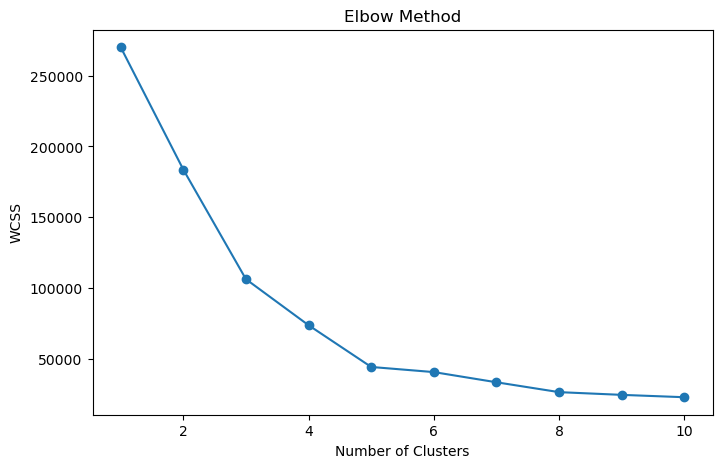

In [13]:
# 5. Finding Optimal Clusters using Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [18]:
# 6. Applying KMeans with Optimal Clusters (k=5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)
import os
os.environ["OMP_NUM_THREADS"]="1"

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [19]:
# 7. Add Cluster Column
df['Cluster'] = y_kmeans

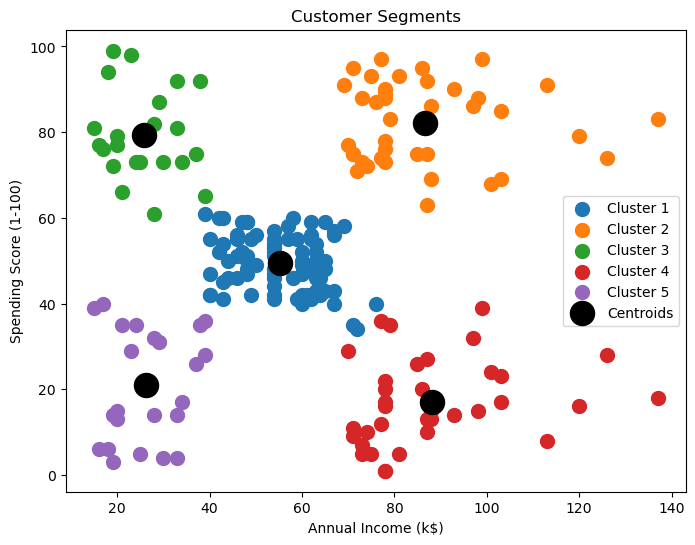

In [20]:
# 8. Visualizing Clusters
plt.figure(figsize=(8,6))

plt.scatter(X[y_kmeans == 0]['Annual Income (k$)'],
            X[y_kmeans == 0]['Spending Score (1-100)'],
            s=100, label='Cluster 1')

plt.scatter(X[y_kmeans == 1]['Annual Income (k$)'],
            X[y_kmeans == 1]['Spending Score (1-100)'],
            s=100, label='Cluster 2')

plt.scatter(X[y_kmeans == 2]['Annual Income (k$)'],
            X[y_kmeans == 2]['Spending Score (1-100)'],
            s=100, label='Cluster 3')

plt.scatter(X[y_kmeans == 3]['Annual Income (k$)'],
            X[y_kmeans == 3]['Spending Score (1-100)'],
            s=100, label='Cluster 4')

plt.scatter(X[y_kmeans == 4]['Annual Income (k$)'],
            X[y_kmeans == 4]['Spending Score (1-100)'],
            s=100, label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300, c='black', label='Centroids')

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


In [21]:
# 9. Saving Output
df.to_csv("Customer_Segmentation_Output.csv", index=False)

print("Clustering Completed Successfully!")


Clustering Completed Successfully!
